# Building a first Classification NN

Use the Ames Mutagenicity dataset (from assignment 1A) and build a binary classifier NN. Play with the model parameters. 

For comparison of the NN model performance, consider the performance of other (baseline) classifier models (assignment 1A):
- KNN: Test-Accuracy 0.79, Test-ROC-AUC 0.86
- Decision Tree: Test-Accuracy 0.78, Test-ROC-AUC 0.77
- Random Forest: Test-Accuracy 0.83, Test-ROC-AUC 0.90
- Gradient Boosting: Test-Accuracy 0.77, Test-ROC-AUC 0.85


#### Tasks:
1) Load the dataset `ames_data.csv`. The dataset does not contain any duplicates or NaNs
2) Feature engineering: Calculate various fingerprints from the SMILES strings via mol objects using RDKit(snippet provided for Morgan FPs and MACCS keys)
3) Create feature matrix and target vector. Choose first the MorganFP (Later repeat the process for other fingerprint types). Convert the training and test sets into pytorch tensors.
4) Build your NN (see below for more info)
5) Train your model on the Morgan Fingerprints (and repeat later for other FP types)
6) Evaluate your model's performance and compare to other classifier models
7) Save the model / current state.
8) Respond to the discussion points


#### Note:
The aim of this exercise is to gain a bit of practice in building a simple NN and to see how different parameters and feature engineering influence the model. Maximum accuracy is not the target. 

There is no need to venture too far into the details or more advanced approaches just yet (e.g. batched training would be complete overkill for this assignment - we will discuss that in the next sessions)

0) Import dependencies and datasets

In [68]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MACCSkeys

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

1) Load and investigate the data

In [69]:
df = pd.read_csv("ames_data.csv")
df.head()

,drug_id,smiles,mutagenicity
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


In [70]:
df.shape

(7278, 3)

In [71]:
df.describe()

,mutagenicity
count,7278.000000
mean,0.546029
std,0.497911
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


2) Generate different fingerprints (try at least one additional FP type as provided in RDKit and use two different fpSizes on one of them) - all of them will be saved in new columns in the Dataframe.

In [72]:
def morganfp2048(mol):
    if mol is None:
        return np.zeros(2048)  
    fp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint(mol)
    return np.array(fp)

def morganfp1024(mol):
    if mol is None:
        return np.zeros(1024)   
    fp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024).GetFingerprint(mol)
    return np.array(fp)

def maccskeys(mol):
    if mol is None:
        return np.zeros(167)   
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df["morganfp2048"] = df["mol"].apply(morganfp2048)
df["morganfp1024"] = df["mol"].apply(morganfp1024)
df["maccskeys"] = df["mol"].apply(maccskeys)

In [73]:
df.head(5)

,drug_id,smiles,mutagenicity,mol,morganfp2048,morganfp1024,maccskeys
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1,<rdkit.Chem.rdchem.Mol object at 0x000001E7001...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1,<rdkit.Chem.rdchem.Mol object at 0x000001E766F...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0,<rdkit.Chem.rdchem.Mol object at 0x000001E7053...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1,<rdkit.Chem.rdchem.Mol object at 0x000001E7053...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1,<rdkit.Chem.rdchem.Mol object at 0x000001E7053...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


3. Create feature matrix and target vector. The snippet below converts the data into numpy arrays. Start with the Morgan Fingerprints (and later return here to apply your modell to different fingerprint types - not all of the fingerprints may have the same length, so you may have to adapt the width of your layers).

Do a train startified test split and convert into pytorch tensors.

### Base Morgan 2048 Fingerprints

In [74]:
X = np.stack(df["morganfp2048"].values)

# target vector
y = df["mutagenicity"].values

# first split: train+validation and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,   # 0.25 of 0.8 = 0.2 -> 60/20/20 overall
    random_state=42,
    stratify=y_trainval
)

# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


4) Build the NN - adhere to some robust standard values. Start simple and train the model on Morgan FP first.

Optimise the model parameters based on observed over-/underfitting. Experiment with different width and depth, as well as other model parameters. Explore some options to prevent overfitting, e.g. Early stopping (e.g. manually by limiting the epochs) or dropouts. 

Note: Since the input layer needs a lot of neurons (e.g. 2048 bit in the MFPs), consider shrinking the widht from layer to layer. 

Hint: If you use `BCELoss()` as loss function, combine it with a `sigmoid` activation in the last layer. If you use `BCEWithLogitsLoss()`, do not specify any activation in the forward pass (`x = self.outputlayer(x)`).

In [ ]:
class BinClassifierNN(nn.Module):
    def __init__(self):
        super(BinClassifierNN, self).__init__()
        # define your model width and depth below
        self.fc1 = nn.Linear(2048, 512)
        self.fc2 = nn.Linear(512, 128)
        self.out = nn.Linear(128, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Specify the forward pass, i.e. activation functions.
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.out(x)
        return x

changing width and depth did not have a positive effect on training the model. Changing the width made training a lot slower though.

In [76]:
# Parameters (change and add as needed)
learning_rate = 0.0007
num_epochs = 200

In [77]:
model = BinClassifierNN()

# choose a loss function for the classification
criterion = nn.BCEWithLogitsLoss()

# choose an optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

5. Train the NN. Note that you may have to squeeze the output (`outputs=models(X_train).squeeze`). This will reduce the actual output of the shape ``[N, 1]`` to ``[N]``, which is comparable to y (The final layer naturally produces a column tensor, which is not directly comparable to the 1D target tensor).

In [78]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")


Epoch 10/200, Train Loss: 0.4879, Validation Loss: 0.4919
Epoch 20/200, Train Loss: 0.2531, Validation Loss: 0.4507
Epoch 30/200, Train Loss: 0.1083, Validation Loss: 0.5569
Epoch 40/200, Train Loss: 0.0347, Validation Loss: 0.7533
Epoch 50/200, Train Loss: 0.0121, Validation Loss: 0.9261
Epoch 60/200, Train Loss: 0.0055, Validation Loss: 1.0212
Epoch 70/200, Train Loss: 0.0033, Validation Loss: 1.0592
Epoch 80/200, Train Loss: 0.0024, Validation Loss: 1.0508
Epoch 90/200, Train Loss: 0.0024, Validation Loss: 1.0274
Epoch 100/200, Train Loss: 0.0024, Validation Loss: 1.0053
Epoch 110/200, Train Loss: 0.0025, Validation Loss: 0.9801
Epoch 120/200, Train Loss: 0.0027, Validation Loss: 0.9605
Epoch 130/200, Train Loss: 0.0026, Validation Loss: 0.9428
Epoch 140/200, Train Loss: 0.0026, Validation Loss: 0.9315
Epoch 150/200, Train Loss: 0.0024, Validation Loss: 0.9186
Epoch 160/200, Train Loss: 0.0023, Validation Loss: 0.9130
Epoch 170/200, Train Loss: 0.0022, Validation Loss: 0.9096
Epoch 

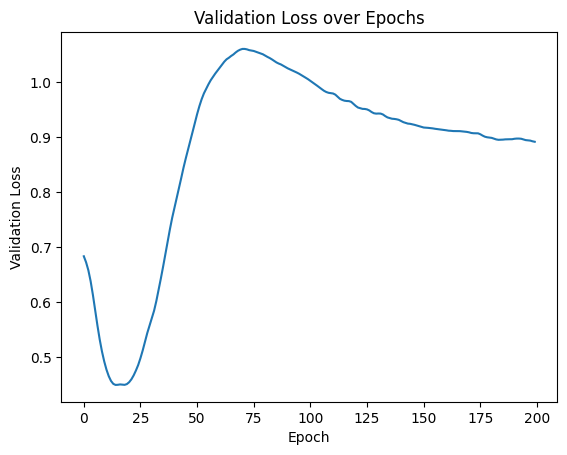

In [79]:
import matplotlib.pyplot as plt

plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over Epochs")
plt.show()


Best model performance on the Morgan2048 FPs with 200 epochs and LR of 0.0007

6) Evaluate the model. As a first metric, you can use the same loss function to evaluate the model on the test set. For better comparison with methods tested in the assignment 1A (results vide supra), use metrics from scikit-learn (e.g. the accuracy or ROC-AUC score).

Hint: for your prediction you may have to use `squeeze` again to match the target vector in the test set (e.g. ``y_pred = model(X_test).squeeze()``)

In [80]:
y_pred = model(X_test)
y_prob = torch.sigmoid(y_pred)
y_class = (torch.sigmoid(y_pred) >= 0.5).float()

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

model.eval()

with torch.no_grad():
    y_logits = model(X_test)
    test_loss = criterion(y_logits, y_test).item()

    y_prob = torch.sigmoid(y_logits).detach().cpu().view(-1).tolist()
    y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
    y_true = y_test.detach().cpu().view(-1).tolist()

accuracy = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Test loss: 1.1556
Accuracy: 0.7699
ROC-AUC: 0.8486


### Morgan 1024 Fingerprints

In [99]:
X = np.stack(df["morganfp1024"].values)

# target vector
y = df["mutagenicity"].values

# first split: train+validation and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25, 
    random_state=42,
    stratify=y_trainval
)

# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


In [100]:
class BinClassifierNN(nn.Module):
    def __init__(self):
        super(BinClassifierNN, self).__init__()
        # define your model width and depth below
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Specify the forward pass, i.e. activation functions.
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.out(x)
        return x


In [101]:
# Parameters (change and add as needed)
learning_rate = 0.0007
num_epochs = 200

In [102]:
model = BinClassifierNN()

# choose a loss function for the classification
criterion = nn.BCEWithLogitsLoss()

# choose an optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [103]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")


Epoch 10/200, Train Loss: 0.6162, Validation Loss: 0.5998
Epoch 20/200, Train Loss: 0.4204, Validation Loss: 0.4901
Epoch 30/200, Train Loss: 0.2927, Validation Loss: 0.4690
Epoch 40/200, Train Loss: 0.1600, Validation Loss: 0.5147
Epoch 50/200, Train Loss: 0.0608, Validation Loss: 0.6484
Epoch 60/200, Train Loss: 0.0187, Validation Loss: 0.8225
Epoch 70/200, Train Loss: 0.0073, Validation Loss: 0.9663
Epoch 80/200, Train Loss: 0.0028, Validation Loss: 1.0692
Epoch 90/200, Train Loss: 0.0018, Validation Loss: 1.1130
Epoch 100/200, Train Loss: 0.0014, Validation Loss: 1.1504
Epoch 110/200, Train Loss: 0.0009, Validation Loss: 1.1684
Epoch 120/200, Train Loss: 0.0008, Validation Loss: 1.1731
Epoch 130/200, Train Loss: 0.0008, Validation Loss: 1.1674
Epoch 140/200, Train Loss: 0.0007, Validation Loss: 1.1711
Epoch 150/200, Train Loss: 0.0009, Validation Loss: 1.1621
Epoch 160/200, Train Loss: 0.0007, Validation Loss: 1.1527
Epoch 170/200, Train Loss: 0.0007, Validation Loss: 1.1389
Epoch 

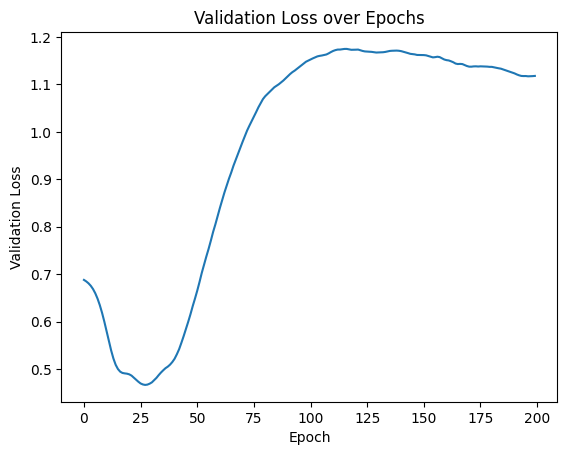

In [104]:
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over Epochs")
plt.show()


In [105]:
y_pred = model(X_test)
y_prob = torch.sigmoid(y_pred)
y_class = (torch.sigmoid(y_pred) >= 0.5).float()

In [106]:
from sklearn.metrics import accuracy_score, roc_auc_score

model.eval()

with torch.no_grad():
    y_logits = model(X_test)
    test_loss = criterion(y_logits, y_test).item()

    y_prob = torch.sigmoid(y_logits).detach().cpu().view(-1).tolist()
    y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
    y_true = y_test.detach().cpu().view(-1).tolist()

accuracy = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Test loss: 1.3645
Accuracy: 0.7837
ROC-AUC: 0.8617


Making the NN wider and adding an additional layer of depth increased the performance a bit.

### MACCS Fingerprints

In [261]:
X = np.stack(df["maccskeys"].values)

# target vector
y = df["mutagenicity"].values

# first split: train+validation and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,   # 0.25 of 0.8 = 0.2 -> 60/20/20 overall
    random_state=42,
    stratify=y_trainval
)

# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


In [262]:
class BinClassifierNN(nn.Module):
    def __init__(self):
        super(BinClassifierNN, self).__init__()
        # define your model width and depth below
        self.fc1 = nn.Linear(167, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.out = nn.Linear(32,1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Specify the forward pass, i.e. activation functions.
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.out(x)
        return x

In [305]:
# Parameters (change and add as needed)
learning_rate = 0.0002
num_epochs = 300

Very small learning rate and a large amount of epochs minimised the training instability and lead to slightly higher results. Going over 300 epochs was inefficient though and did not lead to significantly higher results

In [306]:
model = BinClassifierNN()

# choose a loss function for the classification
criterion = nn.BCEWithLogitsLoss()

# choose an optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [307]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")


Epoch 10/300, Train Loss: 0.6870, Validation Loss: 0.6865
Epoch 20/300, Train Loss: 0.6832, Validation Loss: 0.6816
Epoch 30/300, Train Loss: 0.6766, Validation Loss: 0.6739
Epoch 40/300, Train Loss: 0.6677, Validation Loss: 0.6628
Epoch 50/300, Train Loss: 0.6559, Validation Loss: 0.6476
Epoch 60/300, Train Loss: 0.6380, Validation Loss: 0.6284
Epoch 70/300, Train Loss: 0.6186, Validation Loss: 0.6070
Epoch 80/300, Train Loss: 0.6004, Validation Loss: 0.5871
Epoch 90/300, Train Loss: 0.5839, Validation Loss: 0.5709
Epoch 100/300, Train Loss: 0.5705, Validation Loss: 0.5582
Epoch 110/300, Train Loss: 0.5615, Validation Loss: 0.5461
Epoch 120/300, Train Loss: 0.5472, Validation Loss: 0.5341
Epoch 130/300, Train Loss: 0.5361, Validation Loss: 0.5230
Epoch 140/300, Train Loss: 0.5267, Validation Loss: 0.5135
Epoch 150/300, Train Loss: 0.5151, Validation Loss: 0.5049
Epoch 160/300, Train Loss: 0.5093, Validation Loss: 0.4969
Epoch 170/300, Train Loss: 0.4962, Validation Loss: 0.4897
Epoch 

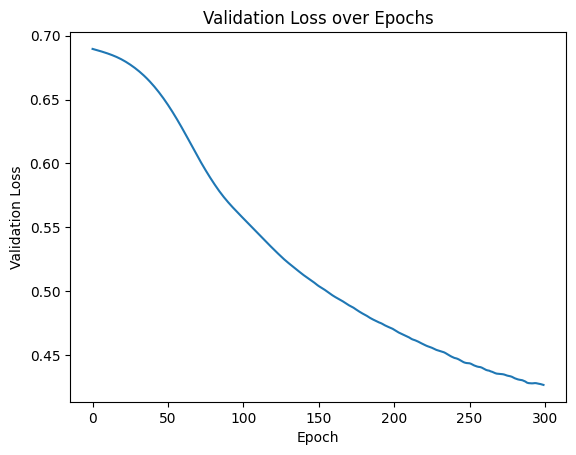

In [308]:
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over Epochs")
plt.show()


In [309]:
y_pred = model(X_test)
y_prob = torch.sigmoid(y_pred)
y_class = (torch.sigmoid(y_pred) >= 0.5).float()

In [310]:

model.eval()

with torch.no_grad():
    y_logits = model(X_test)
    test_loss = criterion(y_logits, y_test).item()

    y_prob = torch.sigmoid(y_logits).detach().cpu().view(-1).tolist()
    y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
    y_true = y_test.detach().cpu().view(-1).tolist()

accuracy = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Test loss: 0.4467
Accuracy: 0.8125
ROC-AUC: 0.8717


Adding an additional layer and making it wider, did not increase performance and from the validation graph, we can see that the training is more unstable than before.

7) Research how you can save the model / current state for later reuse. What are different options here? How can it be loaded again?

In [311]:

#Save model weights
#torch.save(model.state_dict(), "morgan2048_model_weights.pth")

#model = BinClassifierNN()   # need to create same architecture first
#model.load_state_dict(torch.load("morgan2048_model_weights.pth", weights_only=True))
#model.eval()


#Save full checkpoint architecture + weights
#torch.save({
#    "epoch": num_epochs,
#    "model_state_dict": model.state_dict(),
#    "optimizer_state_dict": optimizer.state_dict(),
#    "loss": test_loss
#}, "morgan2048_checkpoint.pth")

#Save full model

#torch.save(model, "full_model.pth")
#model = torch.load("full_model.pth", weights_only=False)
#model.eval()

#### 8) Discussion points
1) How did your model compare to other simple ML classifiers (all used the Morgan FPs)? Discuss!
2) Did you observe any difference between different fingerprint types?
3) Did the fingerprint size impact the model prediction? What message is to be learned from this?
4) What were some model parameters for decent performance depending on the fingerprint type? 
5) Was overfitting a problem? What approaches did you apply to limit that issue? What else would be possible
6) Consider the target "mutagenicity" in the context of molecular structure. What does noise mean here? How could you use such a predictive model in the lab? What other data-driven tools could be interesting in this QSAR context?
7) Why is exporting a full model usually not recommended?

1. The model using the Morgan fingerprint performed quite well and outperformed KNN, Gradient Boosting, and the single Decision Tree, but performance was worse than that of the Random Forest. I think using a simpler approach such as the Random Forest is more effective and requires less tuning and a less complicated architecture. On the other hand, more control over the architecture can improve the model a lot, and I could have added more layers to the models or tried different optimization strategies.
2. The MACCS model performed the best but needed many more epochs, and the training/validation loss became unstable at around 200+ epochs even though the ROC-AUC still increased. I then made the learning rate even smaller but kept the number of epochs the same. This led to slightly better results, but increasing the epochs even more did not make a large difference and was therefore left at 300 for efficiency. The two Morgan fingerprint models performed very similarly, but the 1024 model trained a lot faster because of its lower complexity. It has a lot fewer input features, which reduces computation.
3. The fingerprint size did not change the model much. The two Morgan fingerprint models performed very similarly, even though one used 2048 bits and the other 1024 bits. The best performance was seen for the MACCS model, which had the smallest size, but since MACCS is also a different fingerprint type, this cannot be explained by size alone. It might be that the less complex model still contained all relevant information about mutagenicity while redundant features for this task were removed.
4. The given learning rate was far too high, and I reduced it to 0.0007 for the Morgan models and 0.0002 for the MACCS model, which is quite low. From the validation loss curve, it looked like the model would start to overfit at around epoch 25 for both Morgan fingerprint models, but the ROC-AUC still improved. In the MACCS model, this was the case as well, even though the validation loss became quite unstable at around epoch 200 while performance still improved, so I went to 300 epochs and later decreased the learning rate for more stable training.
5. As described above, the validation loss suggested some overfitting, even though this was not fully reflected in the ROC-AUC. Choosing the stopping point only based on the loss curve would therefore have been bad for the final performance. This shows that both the validation loss and the evaluation metrics should be considered.
6. Noise in this case could mean that mutagenicity may vary and is not explained by the chemical structure alone. It may also be influenced by other conditions such as pH, temperature, assay conditions, or measurement variability, which are not shown in the structure of the molecule itself. These kinds of models can be used in a lab to predict mutagenicity, but actual experiments still need to be done. I believe they could therefore be used as a first screening step and then followed by experimental testing of a compound under different conditions in a lab setting. Clustering techniques could also be used to try and understand similar molecular structures that lead to mutagenicity.
7. Exporting the full model is usually not recommended because it relies on the same class definition and code structure that were used when it was saved. When loading the model again, PyTorch needs access to the original model class with the same name and structure. If the code changes or the environment differs, loading the full model may fail. It is generally better to just save the model parameters because only the learned weights are stored and the model architecture can be rebuilt more easily.

> I also tried making the 2048 model deeper, but this made the performance slightly worse. This might be due to the fact that the model was already able to explain most of the complexity with its original architecture, so the added depth only introduced unnecessary complexity.